In [9]:
import duckdb
csv_file = 'HRDataset_v14.csv'
duckdb.query(f"SELECT * FROM {csv_file}").df()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [13]:
import duckdb
import pandas as pd
csv_file = 'HRDataset_v14.csv'
df = duckdb.query(f"SELECT * FROM {csv_file}").df()
null_count = df.isnull().sum()
null_count[null_count > 0]


DateofTermination    207
ManagerID              8
dtype: int64

In [16]:
import numpy as np
df['ManagerID'] = df['ManagerID'].fillna(0)
df['Employment_status'] = np.where(df['DateofTermination'].isnull(), 'Active', 'Left')
print(df[['ManagerID','Employment_status' ]].isnull().sum())
df[['Employee_Name', 'ManagerID', 'Employment_status']].head()

ManagerID            0
Employment_status    0
dtype: int64


,Employee_Name,ManagerID,Employment_status
0,"Adinolfi, Wilson K",22,Active
1,"Ait Sidi, Karthikeyan",4,Left
2,"Akinkuolie, Sarah",20,Left
3,"Alagbe,Trina",16,Active
4,"Anderson, Carol",39,Left


In [17]:

query_top_person = """
SELECT Employee_Name, Position, Salary
FROM df
ORDER BY Salary DESC
LIMIT 1;
"""
duckdb.query(query_top_person).df()



,Employee_Name,Position,Salary
0,"King, Janet",President & CEO,250000


C:\Users\User\AppData\Local\Temp\ipykernel_12996\1101048395.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Salary', y='Position', data=df_salary_chart, palette='flare')


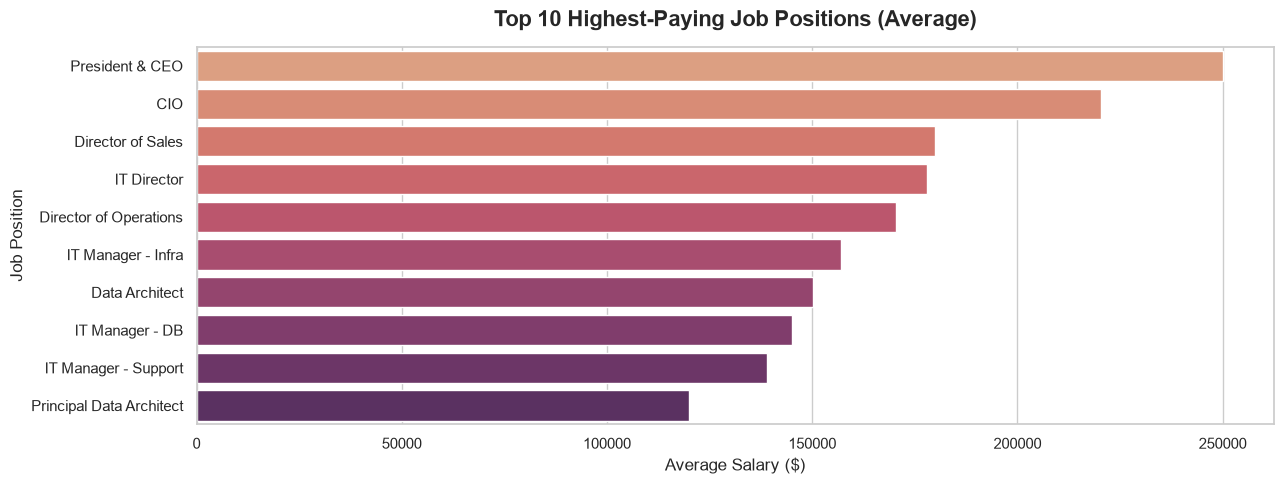

In [13]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

csv_file = "HRDataset_v14.csv"

query_highest_salary = f""" 
SELECT Position, AVG(Salary) AS Average_Salary
FROM '{csv_file}'
GROUP BY Position
ORDER BY Average_Salary DESC
LIMIT 10;
"""
df_salary_chart = duckdb.query(query_highest_salary).df()

plt.figure(figsize=(13, 5))
sns.set_theme(style="whitegrid")

sns.barplot(x='Average_Salary', y='Position', data=df_salary_chart, palette='flare')

plt.title('Top 10 Highest-Paying Job Positions (Average)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Salary ($)', fontsize=12)
plt.ylabel('Job Position', fontsize=12)

plt.tight_layout()
plt.show()


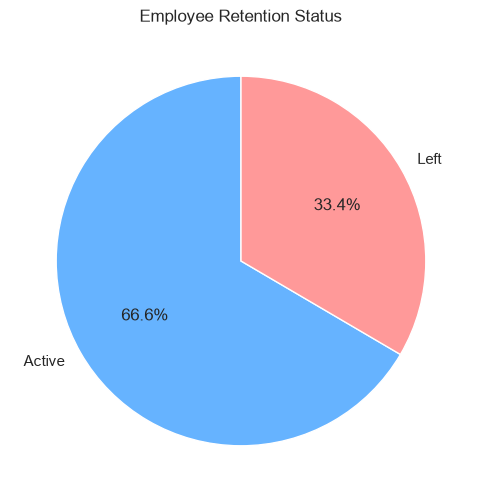

In [14]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_file = "HRDataset_v14.csv"

df = duckdb.query(f"SELECT * FROM '{csv_file}'").df()

df['Employment_status'] = np.where(df['DateofTermination'].isnull(), 'Active', 'Left')

status_counts = df['Employment_status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, 
        labels=status_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#66b3ff', '#ff9999']) 

plt.title('Employee Retention Status')
plt.show()
